# Distance Distribution Analysis

* Assessing scale balance and structure of feature vectors by examining pairwise distances between samples
* Reveals if features contribute unevenly to distance based methods (i.e. euclidean distance) due to different scales

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial.distance import pdist, squareform

In [2]:
np.random.seed(0)
n_samples = 100

## Feature 1: small scale (e.g., age)

In [3]:
feature1 = np.random.normal(loc=30, scale=5, size=n_samples)

## Feature 2: large scale (e.g., income)

In [4]:
feature2 = np.random.normal(loc=50000, scale=15000, size=n_samples)

## Create Dummy Dataset

* `x1`: Small scale features
* `x2`: Large scale features


In [5]:
X_raw = np.vstack((feature1, feature2)).T

## `pdist`: Pair-wise Distance function

* Always accepts a 2-d array
* Computes the distance between each unique pair of samples (rows) in the dataset.
* Returns a 1D array of length `(n(n-1))/2`
* Other possible distance metrics include `euclidean`, `manhattan`, `cosine`. `chebyshev`, `minkowski`

In [6]:
dist_raw = pdist(X_raw, metric='euclidean')

## Normalize Using `MinMaxScaler`

In [7]:
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X_raw)
dist_norm = pdist(X_norm, metric='euclidean')

## Plot histograms of distances

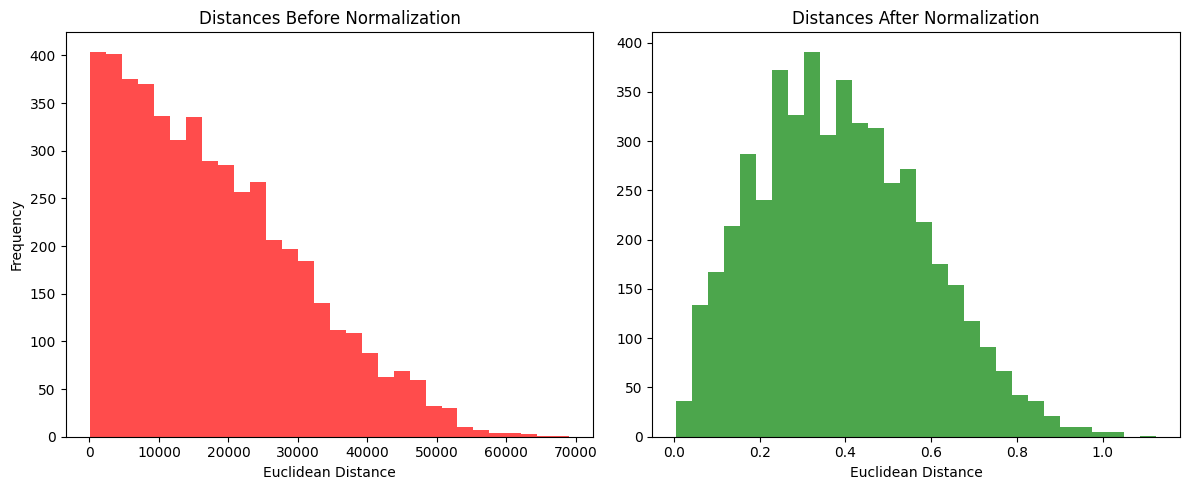

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(dist_raw, bins=30, color='red', alpha=0.7)
plt.title("Distances Before Normalization")
plt.xlabel("Euclidean Distance")
plt.ylabel("Frequency")


plt.subplot(1, 2, 2)
plt.hist(dist_norm, bins=30, color='green', alpha=0.7)
plt.title("Distances After Normalization")
plt.xlabel("Euclidean Distance")

plt.tight_layout()
plt.show()